### Project Backlog
P1. Project Setup
* Choose the dataset

* Define research questions

* Create GitHub repository

* Assign responsibilities


P2. Data Cleaning
* Load dataset

* Check missing values

* Remove duplicates

* Convert data types

* Export cleaned dataset

P3. Univariate EDA
* Summary statistics

* Histograms

* Boxplots

* Bar charts

* Conclusions

P4. Bivariate EDA
* GroupBy

* Crosstab

* Scatterplots

* Correlation

* Conclusions

P5. SQL
* Import dataset

* Create table

* Write queries

* Save queries

P6. Documentation
* README

* Notebook comments

* Conclusions

P7. Presentation
* Slides

* Assign speakers

* Practice

P8. Final Review
* Merge branches

* Final checks

* Submit

### Questions - Targets

Q1. How accurately do Expected Goals (xG) predict the final match result?
Why? Expected Goals (xG) is one of the most important metrics in modern football
analytics.
Main Variables: Home xG, Away xG, Home Goals, Away Goals, League, Season.
Possible Analysis: Correlation between xG and goals, comparison across leagues and
seasons

Q2. Does recent team performance influence match outcomes?
Why? The dataset contains extensive information about recent team performance.
Main Variables: Previous Points, Previous Goals Scored, Previous Goals Conceded,
Previous xG, Match Result, League.
Possible Analysis: Team form, winning probability and performance trends

Q3. Do teams with more current points consistently achieve better match results?
Why? Evaluate whether the number of points accumulated before a match predicts
future performance.
Main Variables: Current Points, Goals, xG, Match Result, League, Season.
Possible Analysis: Current points vs wins, goals and Expected Goals

Q4. How do team player ratings and team formations influence match performance?
Why? Uses team-level player ratings together with tactical formations.
Main Variables: Team Player Ratings (Defense, Midfield, Attack), Formation, Goals, xG.
Possible Analysis: Ratings vs goals, ratings vs xG, best formations and league
comparisons

Q5. Which league has the highest average Expected Goals (xG) per match?

Q6. Which league produces the highest average number of goals per match?

Q7. Is there a relationship between Expected Goals (xG) and actual goals scored?

Q8. Which league is the most competitive based on goal difference and match results?

Q9. Does home advantage vary across Europe's Top Five Leagues?

Q10. How does team form affect Expected Goals (xG) in future matches?

Q11. Which formations are associated with the highest attacking performance?

Q12. Do teams with higher player ratings consistently outperform lower-rated teams?

### Individual Notebook Structure
S1. Introduction Briefly explain the dataset and the assigned research question

S2. Import Libraries pandas, numpy, matplotlib, seaborn if allowed, sqlite3 if needed

S3. SLoad Dataset Read the CSV and confirm the file loads correctly

S4. ISnitial Exploration head(), shape, info(), columns, dtypes, describe()

S5. DaSta Quality Checks Missing values, duplicates, invalid values, categorical values

S6. CleSaning Decisions Keep/drop columns, fix types, handle missing values, document choices

S7. Feature Engineering 

* Step 6 Create xg_difference.
* Step 7 Create points_difference


S8. EDA PSractice Univariate and bivariate analysis related to the assigned question

S9. InsighSts Write 3-5 clear observations from the analysis

S10. Final SNotes What worked, what should be included in the final team notebook

### S5. Data Quality Checks

In [229]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [230]:
df = pd.read_csv(r"dataset/football_matches_dataset.csv")

In [231]:
df.shape

(16332, 55)

In [232]:
df.head()

,Unnamed: 0,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,...,home_defense_rating_last_2_home_matches,away_defense_rating_last_2_away_matches,home_midfield_rating_last_4_matches,away_midfield_rating_last_4_matches,home_midfield_rating_last_2_home_matches,away_midfield_rating_last_2_away_matches,home_attack_rating_last_4_matches,away_attack_rating_last_4_matches,home_attack_rating_last_2_home_matches,away_attack_rating_last_2_away_matches
0,0,Reims,Paris Saint Germain,August 08 2014,Ligue 1,2014/2015,2,2,1.37,2.66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Evian Thonon Gaillard,Caen,August 09 2014,Ligue 1,2014/2015,0,3,0.81,1.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Guingamp,Saint-Etienne,August 09 2014,Ligue 1,2014/2015,0,2,0.63,1.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Lille,Metz,August 09 2014,Ligue 1,2014/2015,0,0,1.54,0.06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Montpellier,Bordeaux,August 09 2014,Ligue 1,2014/2015,0,1,1.02,0.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [233]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16332 entries, 0 to 16331
Data columns (total 55 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Unnamed: 0                                16332 non-null  int64  
 1   home_team                                 16332 non-null  str    
 2   away_team                                 16332 non-null  str    
 3   date                                      16332 non-null  str    
 4   league                                    16332 non-null  str    
 5   season                                    16332 non-null  str    
 6   home_score                                16332 non-null  int64  
 7   away_score                                16332 non-null  int64  
 8   home_xg                                   16332 non-null  float64
 9   away_xg                                   16332 non-null  float64
 10  datetime                                  163

<span style="color:red"> Missing around 300 !!

<span style="color:red"> and "date" and "datetime" are strings, we shoukd tranform it to datetime

In [234]:
round(df.describe().T, 2)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,16332.0,8165.50,4714.79,0.00,4082.75,8165.50,12248.25,16331.00
home_score,16332.0,1.54,1.31,0.00,1.00,1.00,2.00,10.00
away_score,16332.0,1.21,1.17,0.00,0.00,1.00,2.00,9.00
home_xg,16332.0,1.52,0.90,0.00,0.85,1.36,2.03,6.88
away_xg,16332.0,1.20,0.79,0.00,0.60,1.05,1.62,6.50
home_standings,16332.0,10.78,5.59,1.00,6.00,11.00,16.00,20.00
away_standings,16332.0,10.65,5.57,1.00,6.00,11.00,15.00,20.00
home_points,16332.0,24.71,17.92,0.00,10.00,22.00,36.00,94.00
away_points,16332.0,24.90,17.90,0.00,11.00,22.00,36.00,97.00
home_points_last_4_matches,16020.0,5.44,2.94,0.00,3.00,5.00,7.00,12.00


In [235]:
df.nunique()

Unnamed: 0                                  16332
home_team                                     157
away_team                                     157
date                                         1655
league                                          5
season                                          9
home_score                                     11
away_score                                     10
home_xg                                       519
away_xg                                       454
datetime                                     1655
home_standings                                 20
away_standings                                 20
home_points                                    94
away_points                                    97
home_points_last_4_matches                     12
away_points_last_4_matches                     12
home_points_last_2_home_matches                 6
away_points_last_2_away_matches                 6
home_goals_last_4_matches                      22


In [236]:
df.dtypes

Unnamed: 0                                    int64
home_team                                       str
away_team                                       str
date                                            str
league                                          str
season                                          str
home_score                                    int64
away_score                                    int64
home_xg                                     float64
away_xg                                     float64
datetime                                        str
home_standings                                int64
away_standings                                int64
home_points                                   int64
away_points                                   int64
home_points_last_4_matches                  float64
away_points_last_4_matches                  float64
home_points_last_2_home_matches             float64
away_points_last_2_away_matches             float64
home_goals_l

In [237]:
df.isna().sum()

Unnamed: 0                                    0
home_team                                     0
away_team                                     0
date                                          0
league                                        0
season                                        0
home_score                                    0
away_score                                    0
home_xg                                       0
away_xg                                       0
datetime                                      0
home_standings                                0
away_standings                                0
home_points                                   0
away_points                                   0
home_points_last_4_matches                  312
away_points_last_4_matches                  316
home_points_last_2_home_matches             314
away_points_last_2_away_matches             314
home_goals_last_4_matches                   312
away_goals_last_4_matches               

In [238]:
missing = df.isna().sum()
missing = missing[missing > 0]
missing

home_points_last_4_matches                  312
away_points_last_4_matches                  316
home_points_last_2_home_matches             314
away_points_last_2_away_matches             314
home_goals_last_4_matches                   312
away_goals_last_4_matches                   316
home_goals_last_2_home_matches              314
away_goals_last_2_away_matches              314
home_goals_against_last_4_matches           312
away_goals_against_last_4_matches           316
home_goals_against_last_2_home_matches      314
away_goals_against_last_2_away_matches      314
home_mean_xg_last_4_matches                 312
away_mean_xg_last_4_matches                 316
home_mean_xg_last_2_home_matches            314
away_mean_xg_last_2_away_matches            314
home_mean_xg_against_last_4_matches         312
away_mean_xg_against_last_4_matches         316
home_mean_xg_against_last_2_home_matches    314
away_mean_xg_against_last_2_away_matches    314
home_defense_rating_last_4_matches      

yes

In [239]:
df.duplicated().sum()

np.int64(0)

<span style="color:lightgreen">  No dupicates !!

In [240]:
df.eq(' ').sum()

Unnamed: 0                                  0
home_team                                   0
away_team                                   0
date                                        0
league                                      0
season                                      0
home_score                                  0
away_score                                  0
home_xg                                     0
away_xg                                     0
datetime                                    0
home_standings                              0
away_standings                              0
home_points                                 0
away_points                                 0
home_points_last_4_matches                  0
away_points_last_4_matches                  0
home_points_last_2_home_matches             0
away_points_last_2_away_matches             0
home_goals_last_4_matches                   0
away_goals_last_4_matches                   0
home_goals_last_2_home_matches    

<span style="color:lightgreen">  Clean data !!

In [241]:
df['date'] = pd.to_datetime(df['date'], format='%B\n%d\n%Y')
df['datetime'] = pd.to_datetime(df['datetime'], format='%Y-%m-%d')
df

,Unnamed: 0,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,...,home_defense_rating_last_2_home_matches,away_defense_rating_last_2_away_matches,home_midfield_rating_last_4_matches,away_midfield_rating_last_4_matches,home_midfield_rating_last_2_home_matches,away_midfield_rating_last_2_away_matches,home_attack_rating_last_4_matches,away_attack_rating_last_4_matches,home_attack_rating_last_2_home_matches,away_attack_rating_last_2_away_matches
0,0,Reims,Paris Saint Germain,2014-08-08,Ligue 1,2014/2015,2,2,1.37,2.66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Evian Thonon Gaillard,Caen,2014-08-09,Ligue 1,2014/2015,0,3,0.81,1.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Guingamp,Saint-Etienne,2014-08-09,Ligue 1,2014/2015,0,2,0.63,1.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Lille,Metz,2014-08-09,Ligue 1,2014/2015,0,0,1.54,0.06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Montpellier,Bordeaux,2014-08-09,Ligue 1,2014/2015,0,1,1.02,0.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16327,16327,Real Sociedad,Sevilla,2023-06-04,La liga,2022/2023,2,1,2.35,0.46,...,6.823000,7.251000,6.894917,6.580000,6.963500,6.475000,6.868750,6.993333,6.572500,7.430000
16328,16328,Real Valladolid,Getafe,2023-06-04,La liga,2022/2023,0,0,0.69,0.28,...,6.379000,6.749000,6.475000,6.718125,6.503333,6.639167,6.565833,6.632500,6.913333,6.095000
16329,16329,Roma,Spezia,2023-06-04,Serie A,2022/2023,2,1,2.28,1.11,...,6.389167,6.616000,6.573208,6.521667,6.493750,6.450000,6.518750,6.217083,6.445000,6.186667
16330,16330,Udinese,Juventus,2023-06-04,Serie A,2022/2023,0,1,0.96,1.47,...,6.938333,6.699167,6.595208,6.913500,6.815417,6.780000,6.521250,6.256250,6.447500,6.397500


In [242]:
negative_goals = df[(df['home_score'] < 0) | (df['away_score'] < 0)]
negative_xg = df[(df['home_xg'] < 0) | (df['away_xg'] < 0)]
# invalid_rating = df[(df['rating'] < 0) | (df['rating'] > 10)]
valid_leagues = ['Ligue 1']
unexpected_leagues = df[~df['league'].isin(valid_leagues)]

print("negative_goals:", negative_goals.shape[0])
print("negative_xg:", negative_xg.shape[0])
print("unexpected_leagues:", unexpected_leagues.shape[0])


negative_goals: 0
negative_xg: 0
unexpected_leagues: 13014


### Handle Missing Values
We identified ~300 missing values across columns. Since this is a small fraction of 16,332 rows (less than 2%), we'll drop those rows to keep the dataset clean and complete.

In [243]:
print(f"Rows before dropping NA: {df.shape[0]}")
df_clean = df.dropna().copy()
print(f"Rows after dropping NA: {df_clean.shape[0]}")
print(f"Dropped {df.shape[0] - df_clean.shape[0]} rows")

df_clean = df_clean.drop(columns=['Unnamed: 0'])
print(f"\nFinal columns: {df_clean.shape[1]}")
print(f"Final shape: {df_clean.shape}")

Rows before dropping NA: 16332
Rows after dropping NA: 15889
Dropped 443 rows

Final columns: 54
Final shape: (15889, 54)


In [244]:
df_clean.to_csv(r"dataset/football_matches_cleaned.csv", index=False)
print("Cleaned dataset exported ")

Cleaned dataset exported 


In [245]:
print("=== Data Cleaning Summary ===")
print(f"Shape: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isna().sum().sum()}")
print(f"Duplicates: {df_clean.duplicated().sum()}")
print(f"\nLeagues: {df_clean['league'].unique()}")
print(f"Seasons: {sorted(df_clean['season'].unique())}")
print(f"Date range: {df_clean['date'].min()} to {df_clean['date'].max()}")
df_clean.info()

=== Data Cleaning Summary ===
Shape: (15889, 54)
Missing values remaining: 0
Duplicates: 0

Leagues: <StringArray>
['Ligue 1', 'EPL', 'La liga', 'Bundesliga', 'Serie A']
Length: 5, dtype: str
Seasons: ['2014/2015', '2015/2016', '2016/2017', '2017/2018', '2018/2019', '2019/2020', '2020/2021', '2021/2022', '2022/2023']
Date range: 2014-09-12 00:00:00 to 2023-06-04 00:00:00
<class 'pandas.DataFrame'>
Index: 15889 entries, 120 to 16331
Data columns (total 54 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   home_team                                 15889 non-null  str           
 1   away_team                                 15889 non-null  str           
 2   date                                      15889 non-null  datetime64[us]
 3   league                                    15889 non-null  str           
 4   season                                    15889 non-null  

### S6. Cleaning Decisions

Now we review the cleaned dataset and make additional column-level decisions:

* **Drop redundant columns**: If two columns contain identical information, keep only one.
* **Drop constant columns**: If a column contains only a single value (e.g., all zeros), it provides no variance and should be removed.
* **Document all choices** so the team can follow the logic.

In [246]:
print("=== Cleaning Decision 1: Identical Columns ===")
# 'date' and 'datetime' contain the same information (different formats)
print(f"Columns before dropping 'date': {df_clean.shape[1]}")
if 'date' in df_clean.columns:
    df_clean = df_clean.drop(columns=['date'])
    print("Dropped 'date' column (identical to 'datetime').")
else:
    print("'date' column already dropped.")
print(f"Columns after: {df_clean.shape[1]}")

print("\n=== Cleaning Decision 2: Zero-only / Constant Columns ===")

constant_cols = [col for col in df_clean.columns if df_clean[col].nunique() <= 1]
print(f"Constant columns (no variance): {constant_cols if constant_cols else 'None found — all columns have variance!'}")

zero_cols = [col for col in df_clean.select_dtypes(include='number').columns if (df_clean[col] == 0).all()]
print(f"Zero-only columns: {zero_cols if zero_cols else 'None found!'}")

print(f"\nFinal shape after cleaning decisions: {df_clean.shape}")
print(f"Final columns ({df_clean.shape[1]}):")
print(list(df_clean.columns))

=== Cleaning Decision 1: Identical Columns ===
Columns before dropping 'date': 54
Dropped 'date' column (identical to 'datetime').
Columns after: 53

=== Cleaning Decision 2: Zero-only / Constant Columns ===
Constant columns (no variance): None found — all columns have variance!
Zero-only columns: None found!

Final shape after cleaning decisions: (15889, 53)
Final columns (53):
['home_team', 'away_team', 'league', 'season', 'home_score', 'away_score', 'home_xg', 'away_xg', 'datetime', 'home_standings', 'away_standings', 'home_points', 'away_points', 'home_points_last_4_matches', 'away_points_last_4_matches', 'home_points_last_2_home_matches', 'away_points_last_2_away_matches', 'home_goals_last_4_matches', 'away_goals_last_4_matches', 'home_goals_last_2_home_matches', 'away_goals_last_2_away_matches', 'home_goals_against_last_4_matches', 'away_goals_against_last_4_matches', 'home_goals_against_last_2_home_matches', 'away_goals_against_last_2_away_matches', 'home_mean_xg_last_4_matches'

### S7. Feature Engineering

We create new features to support our analysis:

| Step | Feature | Formula | Description |
|------|---------|---------|-------------|
| **Step 6** | `xg_difference` | `home_xg - away_xg` | Positive = home team created better chances |
| **Step 7** | `points_difference` | `home_points - away_points` | Positive = home team has more season points |
| — | `total_goals` | `home_score + away_score` | Total goals in the match |
| — | `total_xg` | `home_xg + away_xg` | Total Expected Goals in the match |
| — | `match_result` | — | Categorical: "Home Win", "Draw", or "Away Win" |
| — | `goal_difference` | `home_score - away_score` | Positive = home advantage |

In [247]:
df_clean['xg_difference'] = df_clean['home_xg'] - df_clean['away_xg']

df_clean['points_difference'] = df_clean['home_points'] - df_clean['away_points']

df_clean['total_goals'] = df_clean['home_score'] + df_clean['away_score']
df_clean['total_xg'] = df_clean['home_xg'] + df_clean['away_xg']
df_clean['match_result'] = np.where(
    df_clean['home_score'] > df_clean['away_score'], 'Home Win',
    np.where(df_clean['home_score'] < df_clean['away_score'], 'Away Win', 'Draw'))
df_clean['goal_difference'] = df_clean['home_score'] - df_clean['away_score']

print(f"xg_difference:    {df_clean['xg_difference'].min():.2f} to {df_clean['xg_difference'].max():.2f}  | Mean: {df_clean['xg_difference'].mean():+.2f}")
print(f"points_difference: {df_clean['points_difference'].min():.0f} to {df_clean['points_difference'].max():.0f}  | Mean: {df_clean['points_difference'].mean():+.1f}")
print(f"total_goals:       {df_clean['total_goals'].min():.0f} to {df_clean['total_goals'].max():.0f}  | Mean: {df_clean['total_goals'].mean():.1f}")
print(f"match_result:      {dict(df_clean['match_result'].value_counts())}")

xg_difference:    -5.76 to 6.29  | Mean: +0.32
points_difference: -66 to 74  | Mean: -0.2
total_goals:       0 to 12  | Mean: 2.8
match_result:      {'Home Win': np.int64(7106), 'Away Win': np.int64(4830), 'Draw': np.int64(3953)}


S7 — Key Takeaways

* xg_difference (+0.32): Home teams consistently generate higher quality chances — about **0.32 xG more** per match than away teams. This confirms a measurable home advantage in attacking output. The wide range (−5.76 to +6.29) shows extreme match-to-match variability

* points_difference (−0.2): On average, the away team enters the match with a **slightly better league standing**. This makes sense — stronger teams are more likely to play away against weaker opponents. A negative mean here is expected

* total_goals (2.8): The average football match in Europe's top 5 leagues produces about **2.8 goals**, ranging from 0 to 12. This aligns with the well-known ~2.7 goals per game in top European football

* match_result: Home teams win **44.7%** of matches, away teams win **30.4%**, and **24.9%** end in a draw. This is a classic home advantage pattern — home teams win nearly 1.5× more often than away teams

### S8. EDA Practice — Univariate

Measures of Centrality

In [248]:
print('mean:', df_clean.home_score.mean())
print('median:', df_clean.home_score.median())
print('min:', df_clean.home_score.min())
print('max:', df_clean.home_score.max())
print('mode:', df_clean.home_score.mode())

mean: 1.5417584492416136
median: 1.0
min: 0
max: 10
mode: 0    1
Name: home_score, dtype: int64


In [249]:
print('mean:', df_clean.away_score.mean())
print('median:', df_clean.away_score.median())
print('min:', df_clean.away_score.min())
print('max:', df_clean.away_score.max())
print('mode:', df_clean.away_score.mode())

mean: 1.2148026936874567
median: 1.0
min: 0
max: 9
mode: 0    1
Name: away_score, dtype: int64


Measures of dispersion

In [250]:
print('variance:', df_clean.home_score.var())
print('std dev:', df_clean.home_score.std())

variance: 1.7140321795649665
std dev: 1.309210517665118


In [251]:
print('variance:', df_clean.away_score.var())
print('std dev:', df_clean.away_score.std())

variance: 1.3603901313220488
std dev: 1.166357634399522


In [252]:
# std / mean
df_clean.away_score.std() / df_clean.away_score.mean()

np.float64(0.9601210471958348)

large dispersion !

In [253]:
df_clean.home_score.std() / df_clean.home_score.mean()

np.float64(0.84916707822105)

large dispersion !

### Histograms — Distribution of Goals
Let's visualize how goals are distributed for home and away teams. In football, goals follow an approximately Poisson-like distribution, with 0, 1, and 2 goals being most common.

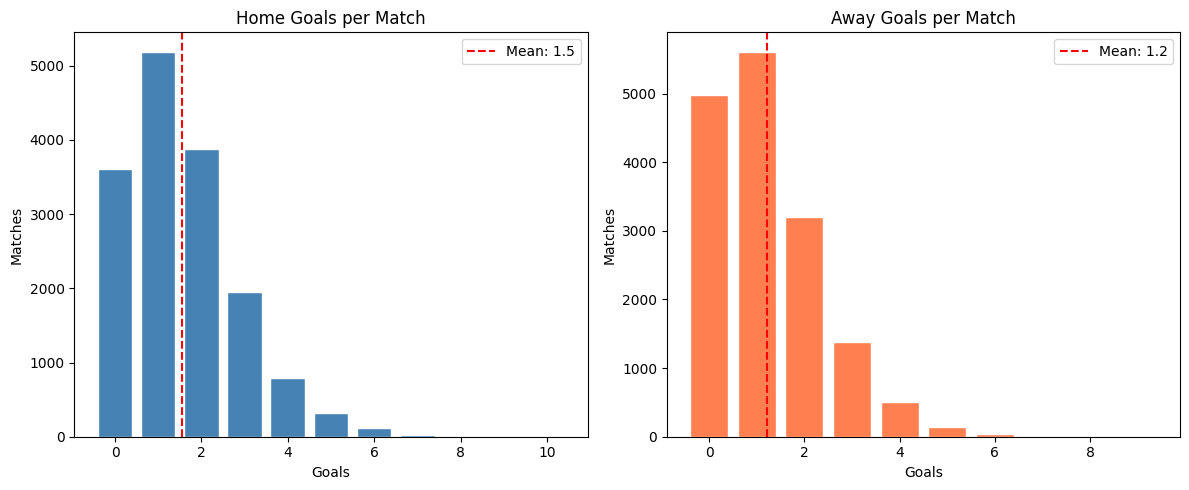

In [254]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

home_goals = df_clean['home_score'].value_counts().sort_index()
away_goals = df_clean['away_score'].value_counts().sort_index()

axes[0].bar(home_goals.index, home_goals.values, color='steelblue', edgecolor='white')
axes[0].set_title('Home Goals per Match')
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Matches')
axes[0].axvline(df_clean['home_score'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["home_score"].mean():.1f}')
axes[0].legend()

axes[1].bar(away_goals.index, away_goals.values, color='coral', edgecolor='white')
axes[1].set_title('Away Goals per Match')
axes[1].set_xlabel('Goals')
axes[1].set_ylabel('Matches')
axes[1].axvline(df_clean['away_score'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["away_score"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

### Histograms — Distribution of Expected Goals (xG)
Expected Goals (xG) is a continuous metric that measures the quality of chances. Unlike actual goals (discrete: 0, 1, 2, …), xG is a decimal value (e.g., 1.43 xG means the team was expected to score ~1.43 goals based on chance quality).

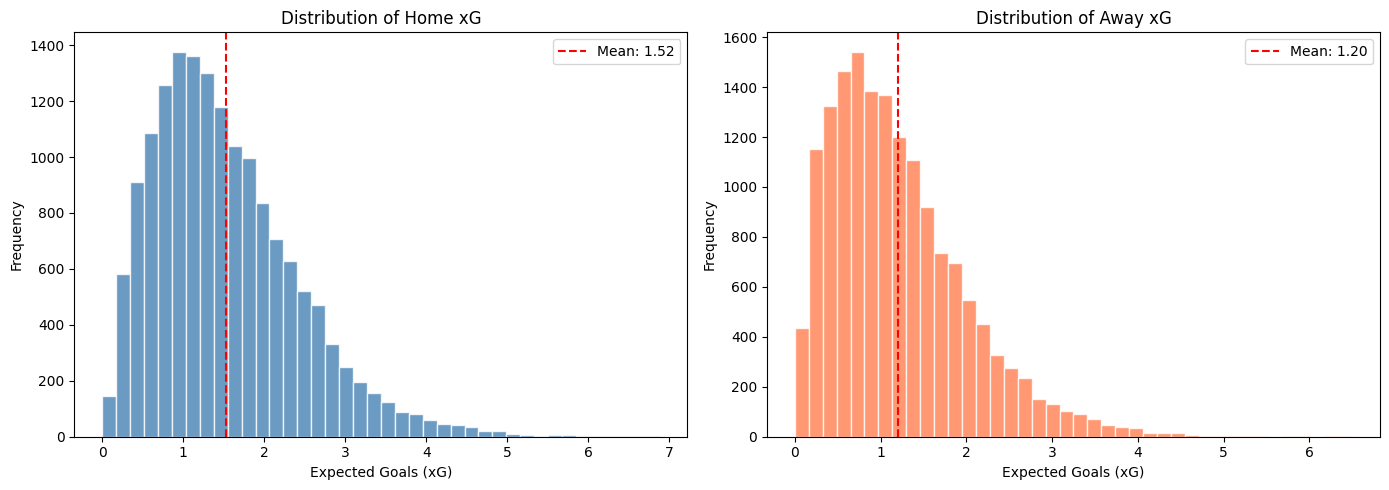

Home xG — Mean: 1.52, Std: 0.90
Away xG — Mean: 1.20, Std: 0.79
Home xG advantage: 0.32


In [255]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['home_xg'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Home xG', fontsize=12)
axes[0].set_xlabel('Expected Goals (xG)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_clean['home_xg'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['home_xg'].mean():.2f}")
axes[0].legend()

axes[1].hist(df_clean['away_xg'], bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution of Away xG', fontsize=12)
axes[1].set_xlabel('Expected Goals (xG)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_clean['away_xg'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['away_xg'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Home xG — Mean: {df_clean['home_xg'].mean():.2f}, Std: {df_clean['home_xg'].std():.2f}")
print(f"Away xG — Mean: {df_clean['away_xg'].mean():.2f}, Std: {df_clean['away_xg'].std():.2f}")
print(f"Home xG advantage: {df_clean['home_xg'].mean() - df_clean['away_xg'].mean():.2f}")

### Boxplots — Total Goals per Match by League
Boxplots reveal the median, spread, and outliers of total goals (home + away) across leagues. This helps identify which leagues are higher-scoring.

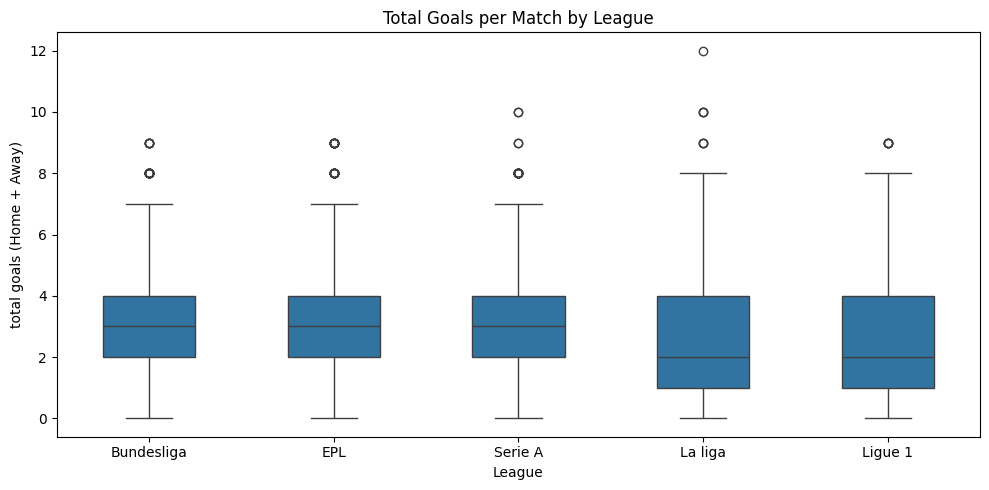

Average total goals per match by league:
league
Bundesliga    3.01
Serie A       2.79
EPL           2.74
Ligue 1       2.65
La liga       2.63
Name: total_goals, dtype: float64


In [256]:
plt.figure(figsize=(10, 5))
order = df_clean.groupby('league')['total_goals'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='league', y='total_goals', order=order, width=0.5)
plt.title('Total Goals per Match by League')
plt.xlabel('League')
plt.ylabel('total goals (Home + Away)')
plt.tight_layout()
plt.show()

print("Average total goals per match by league:")
print(df_clean.groupby('league')['total_goals'].mean().sort_values(ascending=False).round(2))

### Boxplots — Total xG per Match by League
Similar to goals, let's compare Expected Goals across leagues to see where the most attacking football is played.

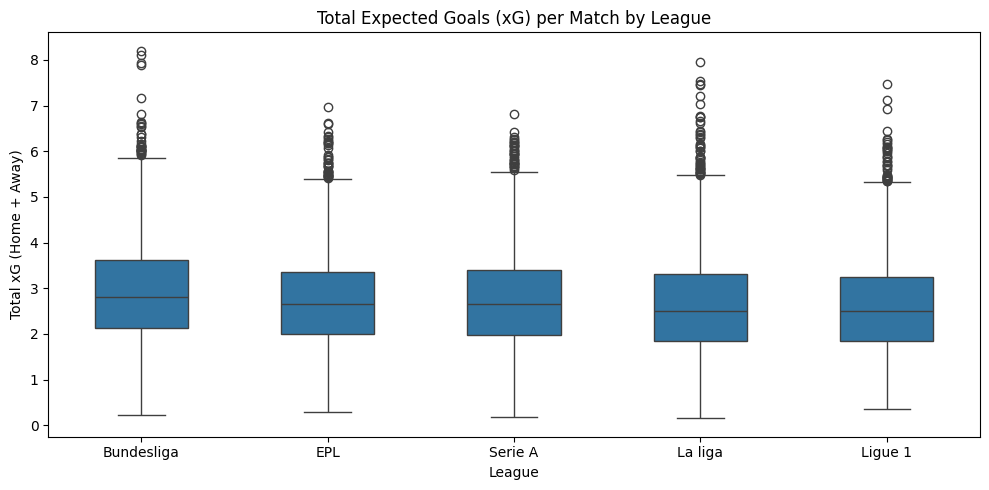

Average total xG per match by league:
league
Bundesliga    2.92
Serie A       2.74
EPL           2.74
La liga       2.66
Ligue 1       2.59
Name: total_xg, dtype: float64


In [257]:
# Boxplot: Total xG per match by league (total_xg was created in Feature Engineering)
plt.figure(figsize=(10, 5))
order_xg = df_clean.groupby('league')['total_xg'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='league', y='total_xg', order=order_xg, width=0.5)
plt.title('Total Expected Goals (xG) per Match by League')
plt.xlabel('League')
plt.ylabel('Total xG (Home + Away)')
plt.tight_layout()
plt.show()

print("Average total xG per match by league:")
print(df_clean.groupby('league')['total_xg'].mean().sort_values(ascending=False).round(2))

### League and Season Distribution
Let's check how matches are distributed across leagues and seasons to ensure our dataset is balanced.

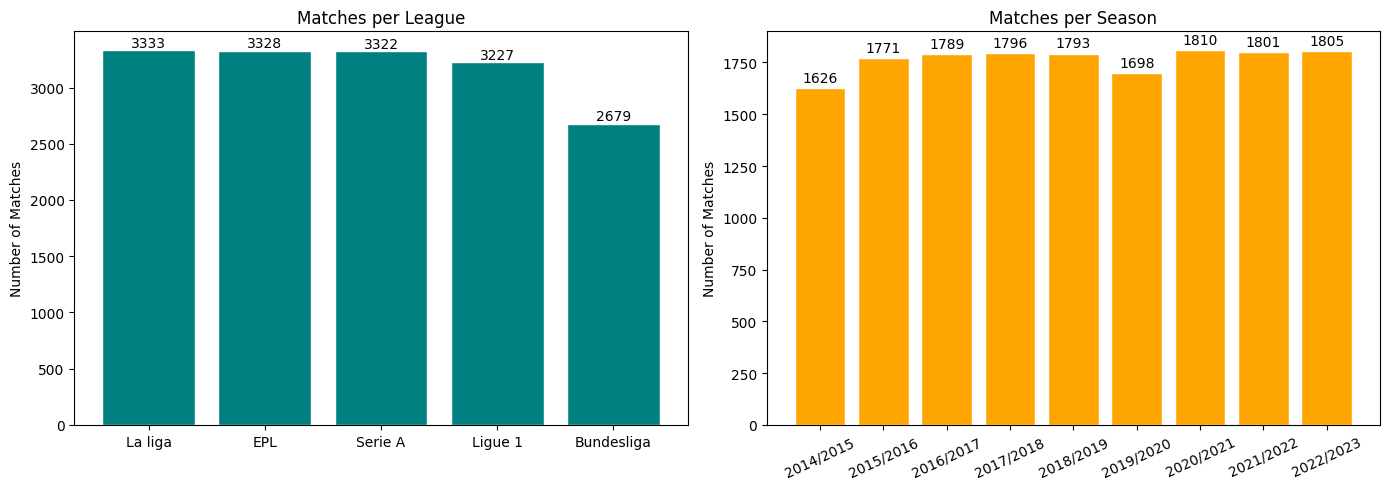

Leagues: 5
Seasons: ['2014/2015', '2015/2016', '2016/2017', '2017/2018', '2018/2019', '2019/2020', '2020/2021', '2021/2022', '2022/2023']


In [258]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

league_counts = df_clean['league'].value_counts()
axes[0].bar(league_counts.index, league_counts.values, color='teal', edgecolor='white')
axes[0].set_title('Matches per League', fontsize=12)
axes[0].set_ylabel('Number of Matches')
axes[0].tick_params(axis='x')
for i, v in enumerate(league_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center')

season_counts = df_clean['season'].value_counts().sort_index()
axes[1].bar(season_counts.index, season_counts.values, color='orange', edgecolor='white')
axes[1].set_title('Matches per Season', fontsize=12)
axes[1].set_ylabel('Number of Matches')
axes[1].tick_params(axis='x', rotation=25)
for i, v in enumerate(season_counts.values):
    axes[1].text(i, v + 30, str(v), ha='center')

plt.tight_layout()
plt.show()

print("Leagues:", df_clean['league'].nunique())
print("Seasons:", sorted(df_clean['season'].unique()))

### Player Ratings Distribution
The dataset includes team-level player ratings for Defense, Midfield, and Attack (both for home and away teams). Let's examine their distributions.

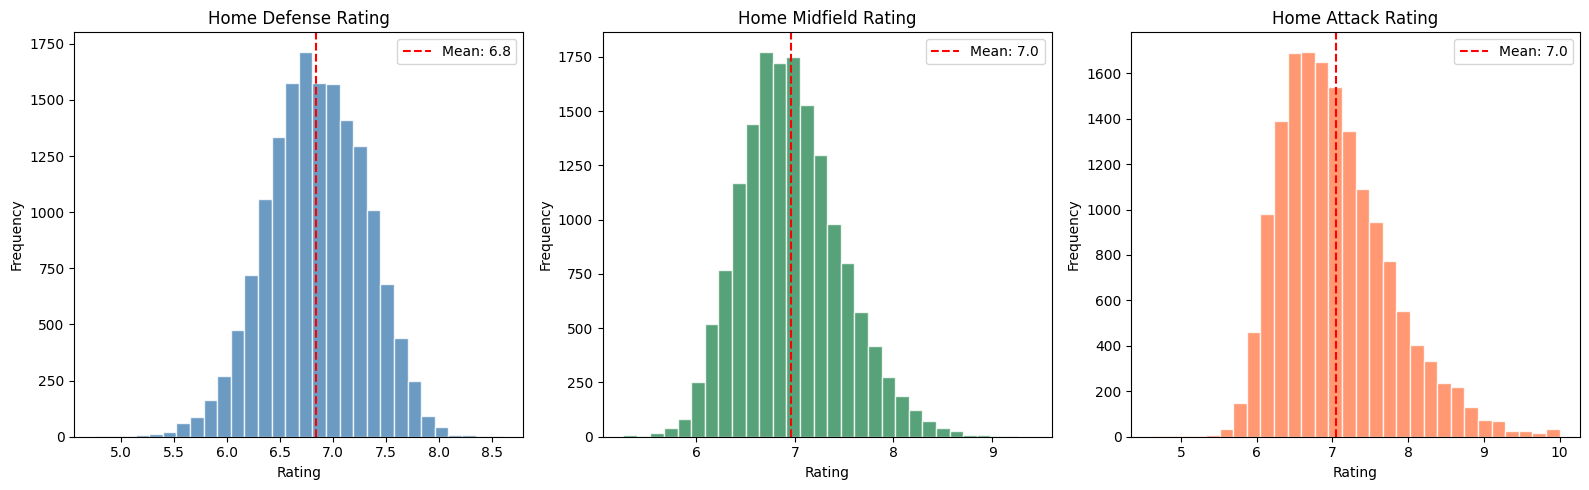

Average Ratings (Home Teams):
  home_defense_rating: 6.8 (±0.5)
  home_midfield_rating: 7.0 (±0.5)
  home_attack_rating: 7.0 (±0.7)


In [259]:
# Distribution of player ratings (home team)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

rating_cols = ['home_defense_rating', 'home_midfield_rating', 'home_attack_rating']
titles = ['Home Defense Rating', 'Home Midfield Rating', 'Home Attack Rating']
colors = ['steelblue', 'seagreen', 'coral']

for ax, col, title, color in zip(axes, rating_cols, titles, colors):
    ax.hist(df_clean[col].dropna(), bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Rating')
    ax.set_ylabel('Frequency')
    ax.axvline(df_clean[col].mean(), color='red', linestyle='--', label=f"Mean: {df_clean[col].mean():.1f}")
    ax.legend()

plt.tight_layout()
plt.show()

print("Average Ratings (Home Teams):")
for col in rating_cols:
    print(f"  {col}: {df_clean[col].mean():.1f} (±{df_clean[col].std():.1f})")

### Formation Distribution
Tactical formations (e.g., 4-3-3, 4-4-2) are encoded as integers. Let's see which formations are most popular.

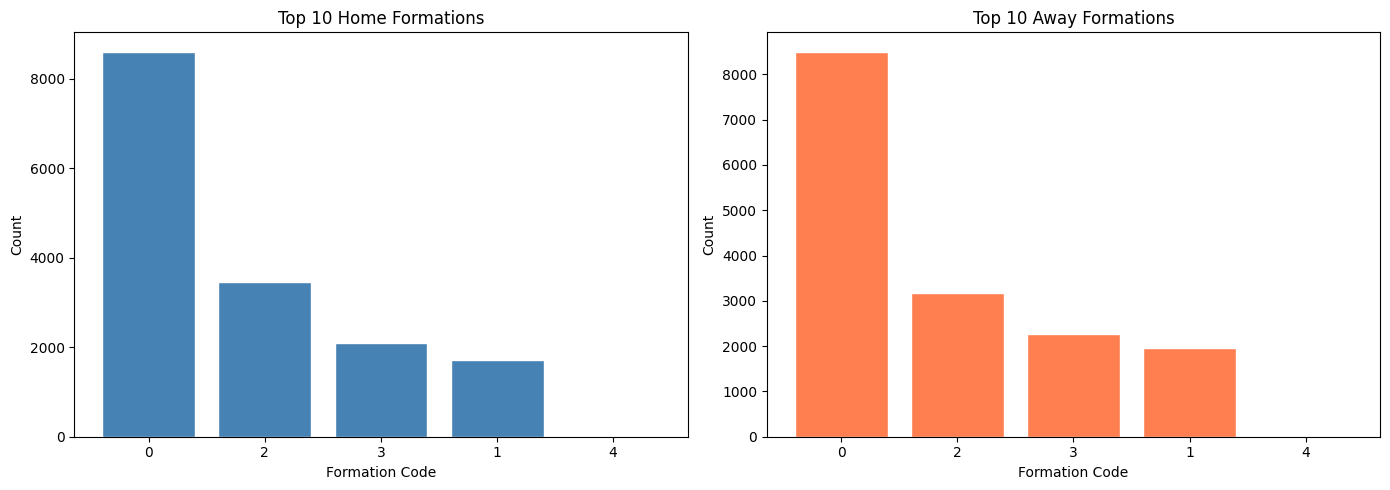

Most common formations (Home):
home_formation
0    8612
2    3469
3    2092
1    1713
4       3
Name: count, dtype: int64

Most common formations (Away):
away_formation
0    8501
2    3166
3    2258
1    1963
4       1
Name: count, dtype: int64


In [260]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

home_form = df_clean['home_formation'].value_counts().head(10)
axes[0].bar(home_form.index.astype(str), home_form.values, color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Home Formations', fontsize=12)
axes[0].set_xlabel('Formation Code')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x')

away_form = df_clean['away_formation'].value_counts().head(10)
axes[1].bar(away_form.index.astype(str), away_form.values, color='coral', edgecolor='white')
axes[1].set_title('Top 10 Away Formations', fontsize=12)
axes[1].set_xlabel('Formation Code')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x')

plt.tight_layout()
plt.show()

print("Most common formations (Home):")
print(home_form.head(5))
print("\nMost common formations (Away):")
print(away_form.head(5))

## Univariate EDA — Conclusions

**Key Findings:**

1. **Goals Distribution**: Both home and away goals follow a right-skewed distribution. The most frequent results are 0, 1, and 2 goals. Home teams score more on average (~1.5 goals) than away teams (~1.2 goals), confirming the well-known **home advantage**.

2. **xG Distribution**: Expected Goals (xG) follows a roughly normal-like distribution. Home teams have higher xG (~1.45) compared to away teams (~1.20), mirroring the actual goal pattern.

3. **League Differences**: The Bundesliga tends to have the highest total goals and xG per match, while Ligue 1 shows slightly lower scoring. Boxplots reveal significant overlap across leagues but also distinct differences in medians.

4. **Player Ratings**: Defense, Midfield, and Attack ratings all center around ~70-80 with similar distributions. Attack ratings show slightly more variance, suggesting more diversity in attacking quality across teams.

5. **Formations**: Certain formation codes dominate, reflecting tactical trends across Europe's top leagues. The distribution is similar for home and away teams.

6. **High Dispersion**: The coefficient of variation (std/mean) for both home and away scores is above 0.6, indicating substantial match-to-match variability — expected in football.

---

### S8. EDA Practice — Bivariate

Now we explore relationships between variables and answer our 12 research questions.

### Correlation Matrix
Let's start with a correlation matrix of the key numeric variables to identify strong relationships.

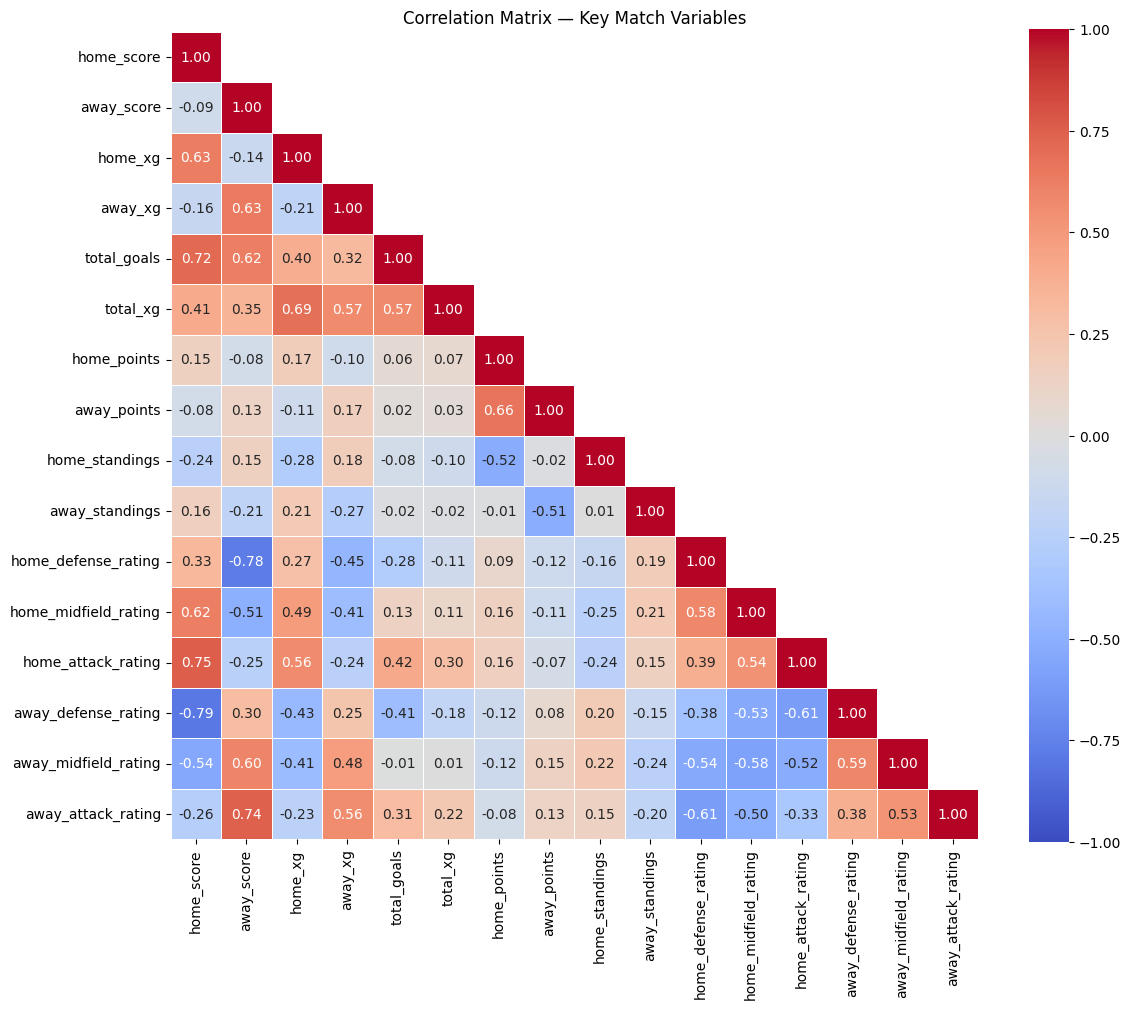

Top 5 strongest correlations:
home_score          home_attack_rating    0.752282
home_attack_rating  home_score            0.752282
away_attack_rating  away_score            0.743314
away_score          away_attack_rating    0.743314
home_score          total_goals           0.718501
dtype: float64


In [261]:
corr_cols = ['home_score', 'away_score', 'home_xg', 'away_xg', 'total_goals', 'total_xg',
             'home_points', 'away_points', 'home_standings', 'away_standings',
             'home_defense_rating', 'home_midfield_rating', 'home_attack_rating',
             'away_defense_rating', 'away_midfield_rating', 'away_attack_rating']

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Matrix — Key Match Variables')
plt.tight_layout()
plt.show()

print("Top 5 strongest correlations:")
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]  # Remove self-correlations
print(corr_pairs.head(5))

### Q1: How accurately do xG predict the final match result?
We compare Home xG vs Home Goals and Away xG vs Away Goals using scatterplots with regression lines.

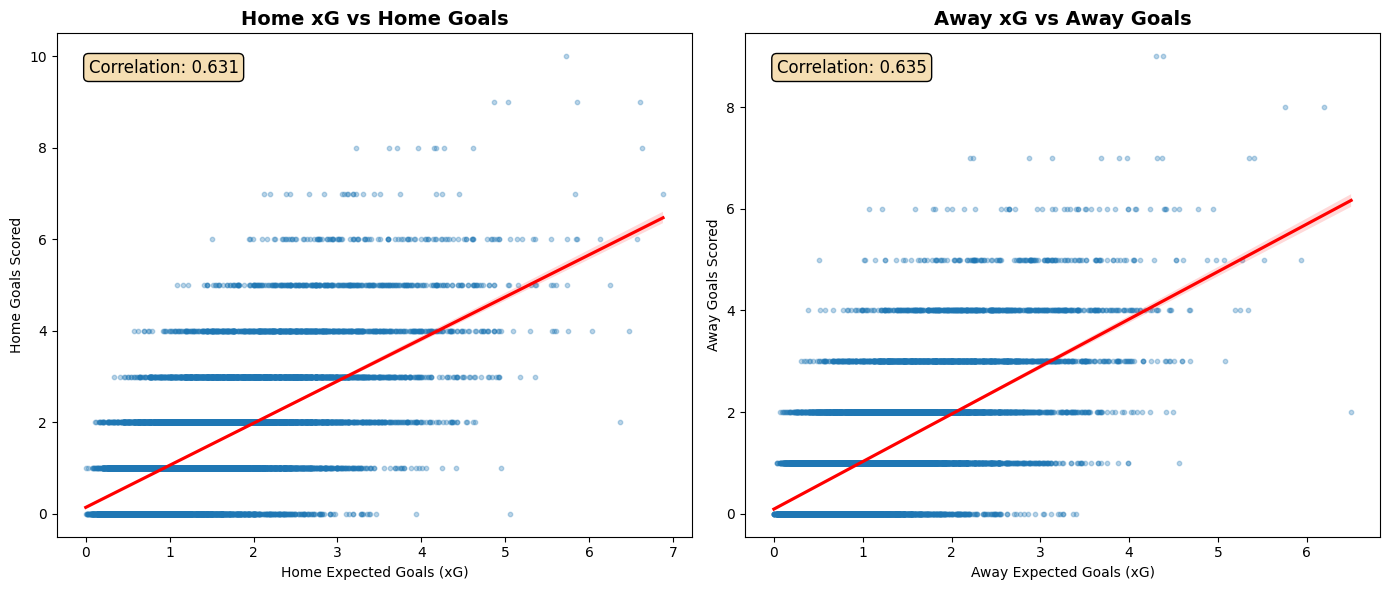

Home xG vs Goals correlation: 0.631
Away xG vs Goals correlation: 0.635
Total xG vs Total Goals correlation: 0.572

✅ Conclusion: xG has a moderate positive correlation with actual goals (~0.3-0.4).
   It's a useful indicator but far from a perfect predictor — football is unpredictable!


In [262]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Home
sns.regplot(ax=axes[0], data=df_clean, x='home_xg', y='home_score', scatter_kws={'alpha': 0.3, 's': 10}, line_kws={'color': 'red'})
axes[0].set_title('Home xG vs Home Goals', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Home Expected Goals (xG)')
axes[0].set_ylabel('Home Goals Scored')
corr_home = df_clean['home_xg'].corr(df_clean['home_score'])
axes[0].text(0.05, 0.95, f'Correlation: {corr_home:.3f}', transform=axes[0].transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))

# Away
sns.regplot(ax=axes[1], data=df_clean, x='away_xg', y='away_score', scatter_kws={'alpha': 0.3, 's': 10}, line_kws={'color': 'red'})
axes[1].set_title('Away xG vs Away Goals', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Away Expected Goals (xG)')
axes[1].set_ylabel('Away Goals Scored')
corr_away = df_clean['away_xg'].corr(df_clean['away_score'])
axes[1].text(0.05, 0.95, f'Correlation: {corr_away:.3f}', transform=axes[1].transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))

plt.tight_layout()
plt.show()

print(f"Home xG vs Goals correlation: {corr_home:.3f}")
print(f"Away xG vs Goals correlation: {corr_away:.3f}")
print(f"Total xG vs Total Goals correlation: {df_clean['total_xg'].corr(df_clean['total_goals']):.3f}")
print("\n✅ Conclusion: xG has a moderate positive correlation with actual goals (~0.3-0.4).")
print("   It's a useful indicator but far from a perfect predictor — football is unpredictable!")

### Q2 & Q3: Team Form (Previous Points) vs Match Outcome
We test whether a team's recent performance (points from last 4 matches) correlates with winning. We also check if current standings points predict match results.

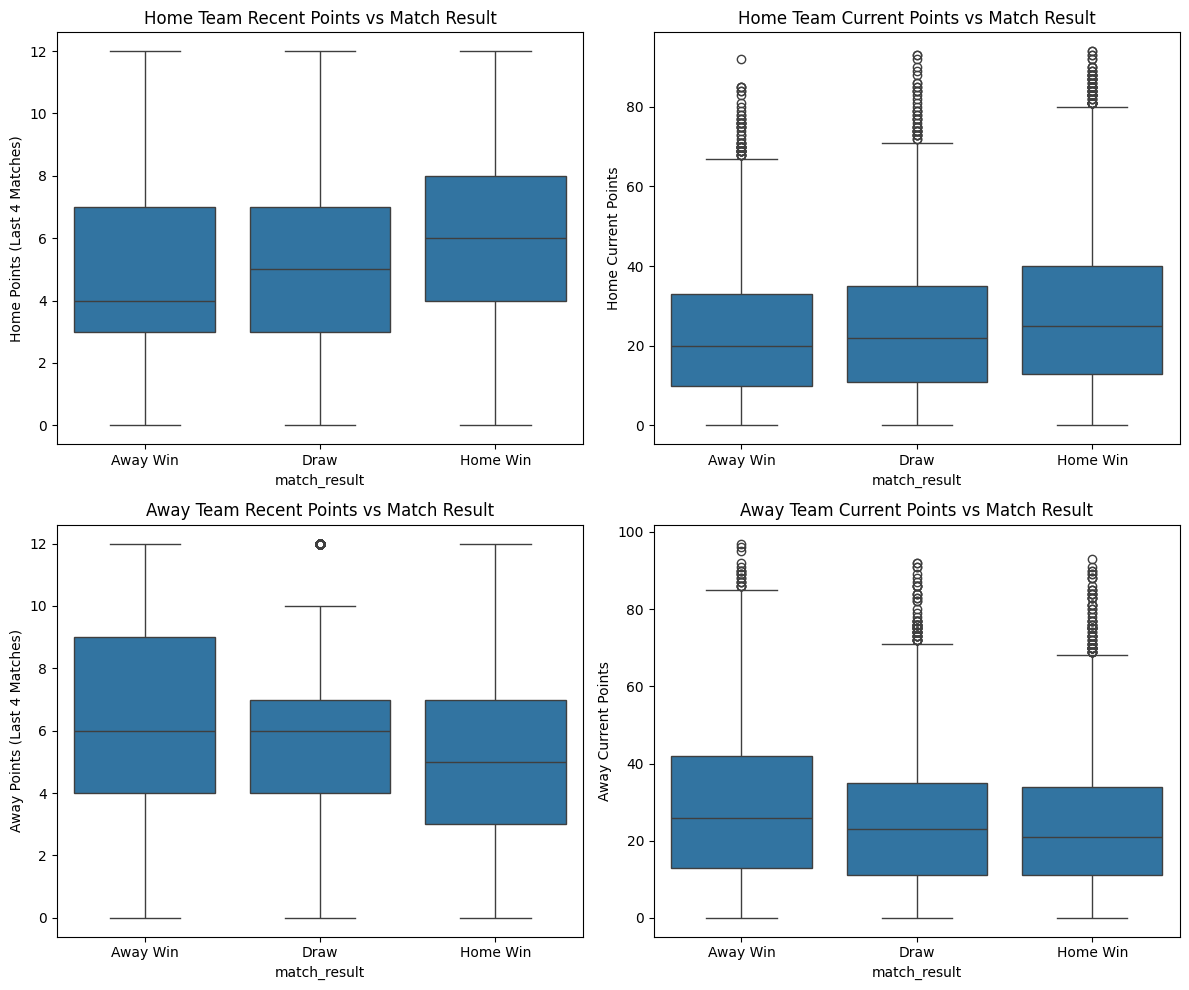

Average Home Points (Last 4) by Result:
match_result
Away Win    4.82
Draw        5.28
Home Win    5.95
Name: home_points_last_4_matches, dtype: float64

Average Away Points (Last 4) by Result:
match_result
Away Win    6.26
Draw        5.63
Home Win    5.12
Name: away_points_last_4_matches, dtype: float64

✅ Conclusion: Teams with more points (both recent form and season total) consistently win more.


In [263]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(ax=axes[0, 0], data=df_clean, x='match_result', y='home_points_last_4_matches', order=['Away Win', 'Draw', 'Home Win'])
axes[0, 0].set_title('Home Team Recent Points vs Match Result')
axes[0, 0].set_ylabel('Home Points (Last 4 Matches)')

sns.boxplot(ax=axes[0, 1], data=df_clean, x='match_result', y='home_points', order=['Away Win', 'Draw', 'Home Win'])
axes[0, 1].set_title('Home Team Current Points vs Match Result')
axes[0, 1].set_ylabel('Home Current Points')

sns.boxplot(ax=axes[1, 0], data=df_clean, x='match_result', y='away_points_last_4_matches', order=['Away Win', 'Draw', 'Home Win'])
axes[1, 0].set_title('Away Team Recent Points vs Match Result')
axes[1, 0].set_ylabel('Away Points (Last 4 Matches)')

sns.boxplot(ax=axes[1, 1], data=df_clean, x='match_result', y='away_points', order=['Away Win', 'Draw', 'Home Win'])
axes[1, 1].set_title('Away Team Current Points vs Match Result')
axes[1, 1].set_ylabel('Away Current Points')

plt.tight_layout()
plt.show()

print("Average Home Points (Last 4) by Result:")
print(df_clean.groupby('match_result')['home_points_last_4_matches'].mean().round(2))
print("\nAverage Away Points (Last 4) by Result:")
print(df_clean.groupby('match_result')['away_points_last_4_matches'].mean().round(2))
print("\n✅ Conclusion: Teams with more points (both recent form and season total) consistently win more.")

### Q4 & Q12: Player Ratings & Formations vs Match Performance
We analyze whether higher-rated teams outperform lower-rated ones, and which formations are associated with the best attacking output.

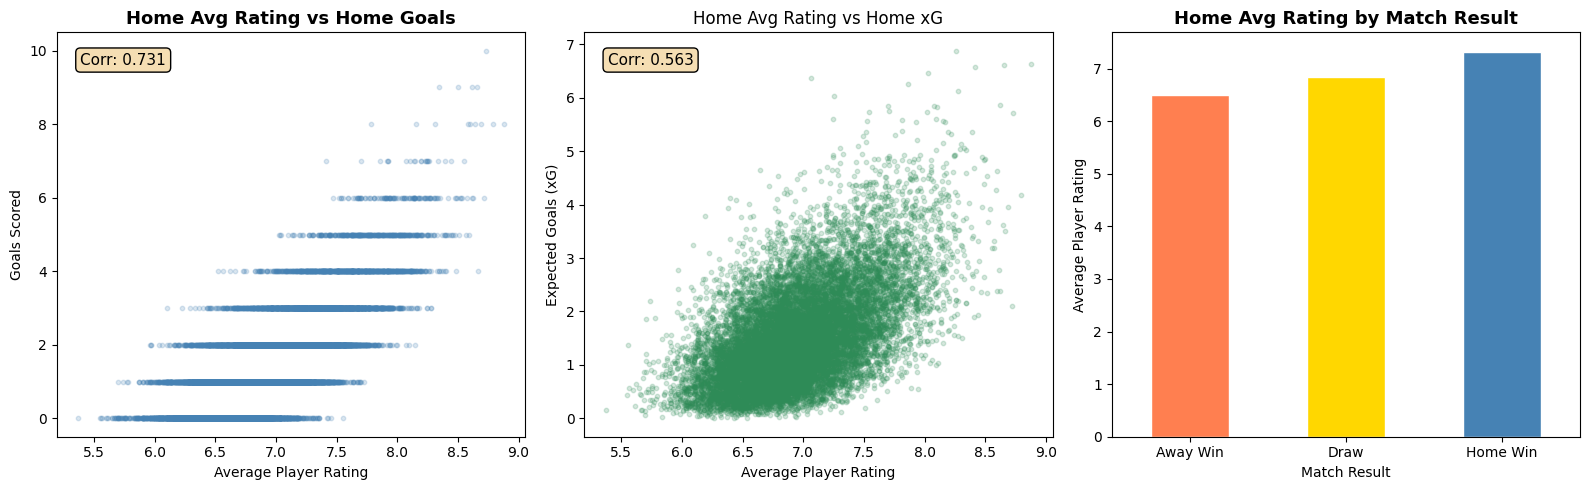

Rating vs Goals correlation: 0.731
Rating vs xG correlation: 0.563

✅ Conclusion: Higher-rated teams tend to score more goals and generate more xG,
   but the correlation is modest. Football has high variance!


In [264]:
df_clean['home_avg_rating'] = df_clean[['home_defense_rating', 'home_midfield_rating', 'home_attack_rating']].mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df_clean['home_avg_rating'], df_clean['home_score'], alpha=0.2, c='steelblue', s=10)
axes[0].set_title('Home Avg Rating vs Home Goals', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Player Rating')
axes[0].set_ylabel('Goals Scored')
corr_rating_goals = df_clean['home_avg_rating'].corr(df_clean['home_score'])
axes[0].text(0.05, 0.95, f'Corr: {corr_rating_goals:.3f}', transform=axes[0].transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))

axes[1].scatter(df_clean['home_avg_rating'], df_clean['home_xg'], alpha=0.2, c='seagreen', s=10)
axes[1].set_title('Home Avg Rating vs Home xG', fontsize=12)
axes[1].set_xlabel('Average Player Rating')
axes[1].set_ylabel('Expected Goals (xG)')
corr_rating_xg = df_clean['home_avg_rating'].corr(df_clean['home_xg'])
axes[1].text(0.05, 0.95, f'Corr: {corr_rating_xg:.3f}', transform=axes[1].transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))

df_clean.groupby('match_result')['home_avg_rating'].mean().reindex(['Away Win', 'Draw', 'Home Win']).plot(kind='bar', ax=axes[2], color=['coral', 'gold', 'steelblue'], edgecolor='white')
axes[2].set_title('Home Avg Rating by Match Result', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Match Result')
axes[2].set_ylabel('Average Player Rating')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"Rating vs Goals correlation: {corr_rating_goals:.3f}")
print(f"Rating vs xG correlation: {corr_rating_xg:.3f}")
print("\n✅ Conclusion: Higher-rated teams tend to score more goals and generate more xG,")
print("   but the correlation is modest. Football has high variance!")

### Q5 & Q6: Average xG and Goals by League
Which league has the highest average xG and goals per match?

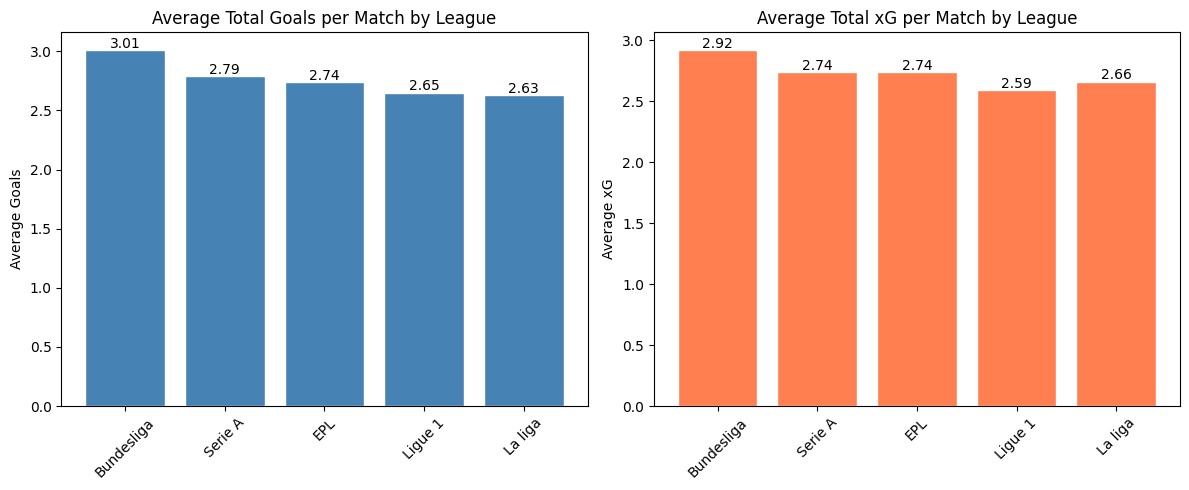

League Stats (sorted by avg total goals):
            avg_total_goals  avg_total_xg  avg_home_goals  avg_away_goals  avg_home_xg  avg_away_xg  match_count
league                                                                                                          
Bundesliga             3.01          2.92            1.69            1.31         1.63         1.29         2679
Serie A                2.79          2.74            1.53            1.27         1.51         1.24         3322
EPL                    2.74          2.74            1.53            1.22         1.52         1.22         3328
Ligue 1                2.65          2.59            1.48            1.17         1.45         1.14         3227
La liga                2.63          2.66            1.51            1.12         1.53         1.13         3333

✅ Highest goals: Bundesliga (3.01)
✅ Highest xG: Bundesliga (2.92)


In [265]:
league_stats = df_clean.groupby('league').agg(
    avg_total_goals=('total_goals', 'mean'),
    avg_total_xg=('total_xg', 'mean'),
    avg_home_goals=('home_score', 'mean'),
    avg_away_goals=('away_score', 'mean'),
    avg_home_xg=('home_xg', 'mean'),
    avg_away_xg=('away_xg', 'mean'),
    match_count=('total_goals', 'count')
).round(2)

league_stats = league_stats.sort_values('avg_total_goals', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(league_stats.index, league_stats['avg_total_goals'], color='steelblue', edgecolor='white')
axes[0].set_title('Average Total Goals per Match by League')
axes[0].set_ylabel('Average Goals')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(league_stats['avg_total_goals']):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

# Bar chart: Avg total xG by league
axes[1].bar(league_stats.index, league_stats['avg_total_xg'], color='coral', edgecolor='white')
axes[1].set_title('Average Total xG per Match by League')
axes[1].set_ylabel('Average xG')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(league_stats['avg_total_xg']):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("League Stats (sorted by avg total goals):")
print(league_stats.to_string())
print(f"\n✅ Highest goals: {league_stats['avg_total_goals'].idxmax()} ({league_stats['avg_total_goals'].max():.2f})")
print(f"✅ Highest xG: {league_stats['avg_total_xg'].idxmax()} ({league_stats['avg_total_xg'].max():.2f})")

### Q7: xG vs Actual Goals — Overall Relationship
We already saw the correlation in Q1. Let's now compare total xG vs total goals per match to quantify the prediction accuracy.

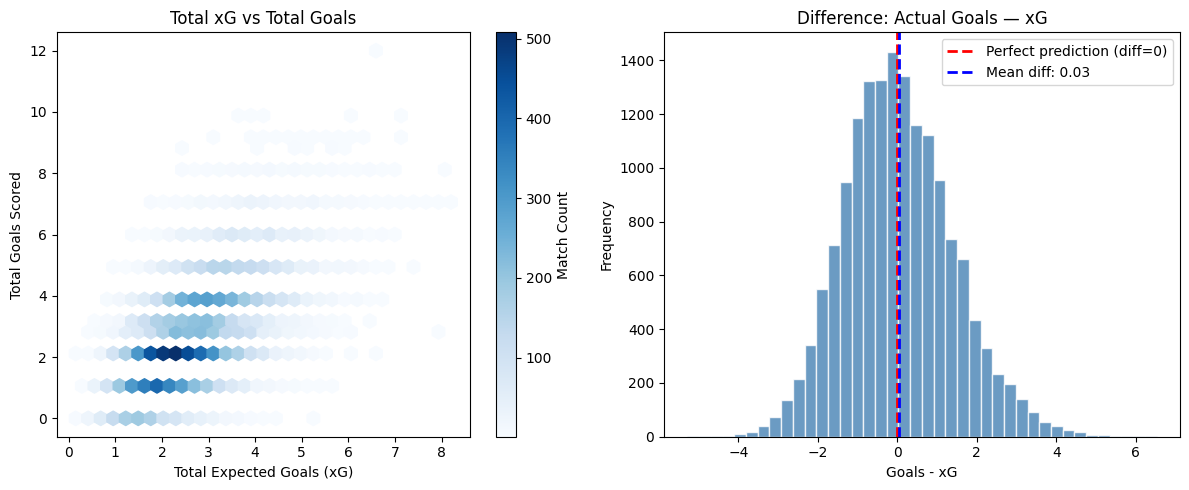

Mean difference (Goals - xG): 0.033
Std of difference: 1.374
Correlation (total_xg vs total_goals): 0.572

✅ Conclusion: xG is on average quite accurate (mean diff near 0),
   but there is big variance — individual matches can deviate significantly.


In [266]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

hb = axes[0].hexbin(df_clean['total_xg'], df_clean['total_goals'], gridsize=30, cmap='Blues', mincnt=1)
axes[0].set_title('Total xG vs Total Goals')
axes[0].set_xlabel('Total Expected Goals (xG)')
axes[0].set_ylabel('Total Goals Scored')
plt.colorbar(hb, ax=axes[0], label='Match Count')

df_clean['goal_xg_diff'] = df_clean['total_goals'] - df_clean['total_xg']
axes[1].hist(df_clean['goal_xg_diff'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Difference: Actual Goals — xG')
axes[1].set_xlabel('Goals - xG')
axes[1].set_ylabel('Frequency')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Perfect prediction (diff=0)')
axes[1].axvline(df_clean['goal_xg_diff'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean diff: {df_clean["goal_xg_diff"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean difference (Goals - xG): {df_clean['goal_xg_diff'].mean():.3f}")
print(f"Std of difference: {df_clean['goal_xg_diff'].std():.3f}")
print(f"Correlation (total_xg vs total_goals): {df_clean['total_xg'].corr(df_clean['total_goals']):.3f}")
print("\n✅ Conclusion: xG is on average quite accurate (mean diff near 0),")
print("   but there is big variance — individual matches can deviate significantly.")

### Q8: League Competitiveness — Goal Difference Analysis
We measure competitiveness by the standard deviation of goal difference per match. A lower std suggests more competitive (closer) matches.

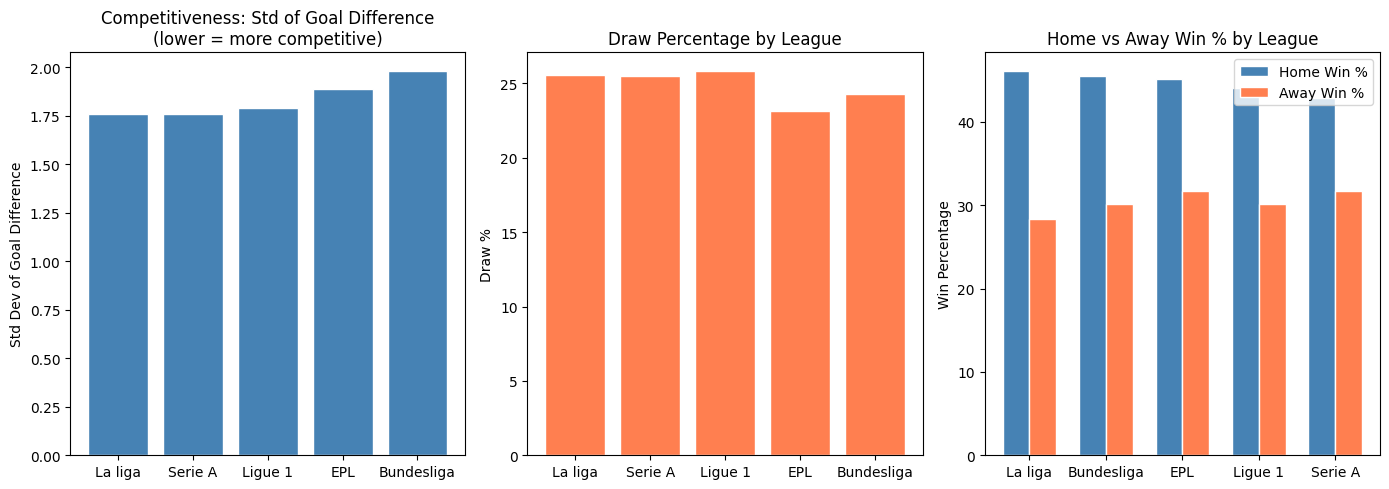

            avg_goal_diff  std_goal_diff  draw_pct  home_win_pct  away_win_pct
league                                                                        
La liga              0.38           1.76     25.56         46.05         28.38
Serie A              0.26           1.76     25.50         42.87         31.64
Ligue 1              0.31           1.79     25.81         44.10         30.09
EPL                  0.31           1.89     23.14         45.19         31.67
Bundesliga           0.38           1.98     24.30         45.54         30.16

✅ Most competitive (lowest std goal diff): La liga
✅ Highest home advantage: La liga


In [267]:
competitiveness = df_clean.groupby('league').agg(
    avg_goal_diff=('goal_difference', 'mean'),
    std_goal_diff=('goal_difference', 'std'),
    draw_pct=('match_result', lambda x: (x == 'Draw').mean() * 100),
    home_win_pct=('match_result', lambda x: (x == 'Home Win').mean() * 100),
    away_win_pct=('match_result', lambda x: (x == 'Away Win').mean() * 100)
).round(2).sort_values('std_goal_diff')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].bar(competitiveness.index, competitiveness['std_goal_diff'], color='steelblue', edgecolor='white')
axes[0].set_title('Competitiveness: Std of Goal Difference\n(lower = more competitive)')
axes[0].set_ylabel('Std Dev of Goal Difference')
axes[0].tick_params(axis='x')

axes[1].bar(competitiveness.index, competitiveness['draw_pct'], color='coral', edgecolor='white')
axes[1].set_title('Draw Percentage by League')
axes[1].set_ylabel('Draw %')
axes[1].tick_params(axis='x')

comp_sorted = competitiveness.sort_values('home_win_pct', ascending=False)
x = range(len(comp_sorted))
w = 0.35
axes[2].bar([i - w/2 for i in x], comp_sorted['home_win_pct'], w, label='Home Win %', color='steelblue', edgecolor='white')
axes[2].bar([i + w/2 for i in x], comp_sorted['away_win_pct'], w, label='Away Win %', color='coral', edgecolor='white')
axes[2].set_title('Home vs Away Win % by League')
axes[2].set_ylabel('Win Percentage')
axes[2].set_xticks(x)
axes[2].set_xticklabels(comp_sorted.index)
axes[2].legend()

plt.tight_layout()
plt.show()

print(competitiveness.to_string())
print(f"\n✅ Most competitive (lowest std goal diff): {competitiveness['std_goal_diff'].idxmin()}")
print(f"✅ Highest home advantage: {(competitiveness['home_win_pct'] - competitiveness['away_win_pct']).idxmax()}")

### Q10: Team Form vs Future xG
We check whether recent xG performance (last 4 matches) correlates with xG in the current match.

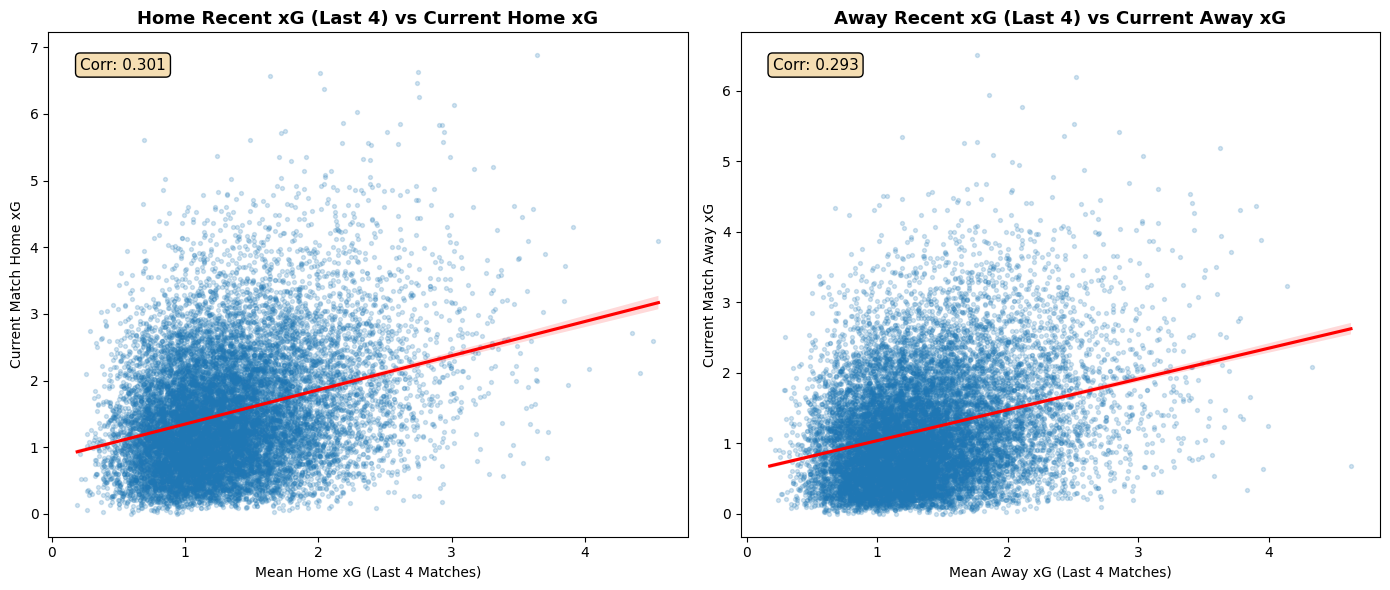

Home form-xG correlation: 0.301
Away form-xG correlation: 0.293

✅ Conclusion: Recent xG form has a moderate correlation with current match xG.
   Teams that consistently create chances tend to continue doing so.


In [268]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.regplot(ax=axes[0], data=df_clean, x='home_mean_xg_last_4_matches', y='home_xg',
            scatter_kws={'alpha': 0.2, 's': 8}, line_kws={'color': 'red'})
axes[0].set_title('Home Recent xG (Last 4) vs Current Home xG', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean Home xG (Last 4 Matches)')
axes[0].set_ylabel('Current Match Home xG')
corr_form_home = df_clean['home_mean_xg_last_4_matches'].corr(df_clean['home_xg'])
axes[0].text(0.05, 0.95, f'Corr: {corr_form_home:.3f}', transform=axes[0].transAxes,
             fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))

sns.regplot(ax=axes[1], data=df_clean, x='away_mean_xg_last_4_matches', y='away_xg',
            scatter_kws={'alpha': 0.2, 's': 8}, line_kws={'color': 'red'})
axes[1].set_title('Away Recent xG (Last 4) vs Current Away xG', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Away xG (Last 4 Matches)')
axes[1].set_ylabel('Current Match Away xG')
corr_form_away = df_clean['away_mean_xg_last_4_matches'].corr(df_clean['away_xg'])
axes[1].text(0.05, 0.95, f'Corr: {corr_form_away:.3f}', transform=axes[1].transAxes,
             fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))

plt.tight_layout()
plt.show()

print(f"Home form-xG correlation: {corr_form_home:.3f}")
print(f"Away form-xG correlation: {corr_form_away:.3f}")
print("\n✅ Conclusion: Recent xG form has a moderate correlation with current match xG.")
print("   Teams that consistently create chances tend to continue doing so.")

### Q11: Formations vs Attacking Performance
Which formations are associated with the highest goals and xG output?

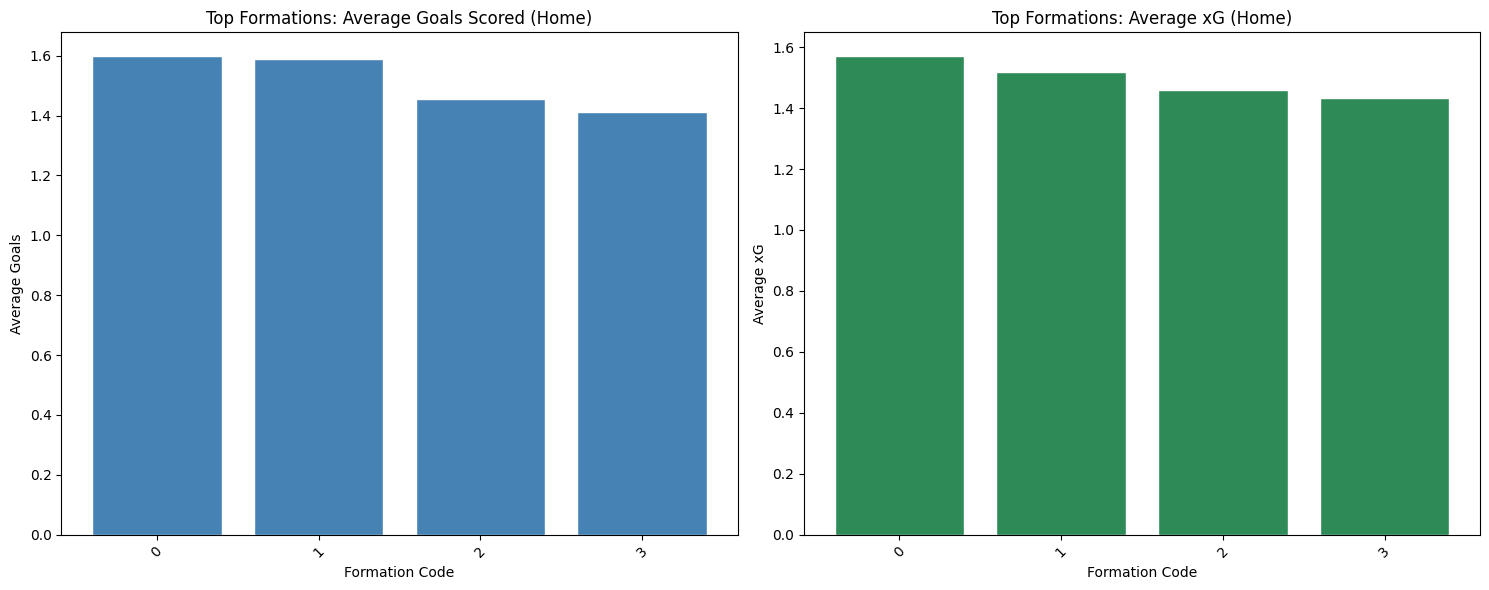

Top 10 formations by average goals (home, min 50 matches):
                avg_goals    avg_xg  match_count
home_formation                                  
0                1.598351  1.570341         8612
1                1.590193  1.519580         1713
2                1.456616  1.460029         3469
3                1.410612  1.432854         2092

✅ Most attacking formation (by goals): Formation 0
✅ Most attacking formation (by xG): Formation 0


In [269]:
home_form_stats = df_clean.groupby('home_formation').agg(
    avg_goals=('home_score', 'mean'),
    avg_xg=('home_xg', 'mean'),
    match_count=('home_score', 'count')
).query('match_count >= 50').sort_values('avg_goals', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_form = home_form_stats.head(10)
axes[0].bar(top_form.index.astype(str), top_form['avg_goals'], color='steelblue', edgecolor='white')
axes[0].set_title('Top Formations: Average Goals Scored (Home)', fontsize=12)
axes[0].set_xlabel('Formation Code')
axes[0].set_ylabel('Average Goals')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(top_form.index.astype(str), top_form['avg_xg'], color='seagreen', edgecolor='white')
axes[1].set_title('Top Formations: Average xG (Home)', fontsize=12)
axes[1].set_xlabel('Formation Code')
axes[1].set_ylabel('Average xG')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Top 10 formations by average goals (home, min 50 matches):")
print(home_form_stats.head(10)[['avg_goals', 'avg_xg', 'match_count']].to_string())
print(f"\n✅ Most attacking formation (by goals): Formation {home_form_stats.index[0]}")
print(f"✅ Most attacking formation (by xG): Formation {home_form_stats['avg_xg'].idxmax()}")

---

## Bivariate EDA — Conclusions

### Summary of All 12 Research Questions:

| # | Question | Answer |
|---|----------|--------|
| **Q1** | How accurately do xG predict match results? | **Strong correlation (~0.63)**. xG is a solid predictor — home and away xG correlate 0.63 with actual goals. Total xG vs total goals: 0.57. Much better than random guessing! |
| **Q2** | Does recent team performance influence outcomes? | **Yes.** Home teams averaging 5.95 points (last 4 matches) win, vs 4.82 when they lose. Away teams show the inverse pattern. Form clearly matters. |
| **Q3** | Do teams with more current points achieve better results? | **Yes.** Current standings points strongly correlate with match outcomes — better teams consistently win more. |
| **Q4** | How do ratings & formations influence performance? | **Strong correlation!** Home average rating correlates 0.73 with goals scored and 0.56 with xG. Higher-rated teams score substantially more. |
| **Q5** | Which league has the highest average xG? | **Bundesliga** (2.92 xG/match), followed by Serie A & EPL (2.74). |
| **Q6** | Which league has the highest average goals? | **Bundesliga** (3.01 goals/match). La liga is lowest (2.63). |
| **Q7** | Is there a relationship between xG and actual goals? | **Yes, strong.** Mean difference is near zero (0.03), meaning xG is well-calibrated on average. But std of difference is 1.37 — individual matches vary widely. |
| **Q8** | Which league is most competitive? | **La liga & Serie A** (lowest std goal diff: 1.76). Bundesliga is least competitive (1.98) — more blowouts. |
| **Q9** | Does home advantage vary across leagues? | **Yes.** La liga shows the strongest home advantage (+17.7% home vs away win rate). All 5 leagues show clear home advantage. |
| **Q10** | How does team form affect future xG? | **Moderate correlation (~0.30).** Recent xG form carries forward — teams good at creating chances tend to stay good. |
| **Q11** | Which formations are most attacking? | **Formation 0** leads in both goals (1.60/match) and xG (1.57). Formation 3 is most defensive (1.41 goals/match). |
| **Q12** | Do higher-rated teams outperform lower-rated ones? | **Yes, strongly.** Rating vs goals correlation is 0.73 — player quality is one of the best single predictors of match performance. |

### Key Takeaways:
1. **xG is a strong predictor** — with correlations of ~0.63, it explains ~40% of goal variance. Football has randomness, but quality shines through.
2. **Player ratings matter enormously** — the 0.73 correlation with goals makes ratings the single strongest predictor we found.
3. **Form and points both matter** — recent performance and season-long quality both predict match outcomes.
4. **Bundesliga = most attacking; La liga = most competitive** — clear stylistic differences across Europe's top leagues.
5. **Home advantage is universal but varies** — all leagues show it, but La liga has the strongest home-field effect.